## DSAN 6000 Homework 4: Optimized Data Queries with Parquet and DuckDB

> **Note**: If you run into RAM overflow issues at any point in the assignment (which will be indicated by, e.g., the kernel or the Python process being killed), you can switch from using `s3://dsan6000-data/acled_events.parquet` as the main data file to `s3://dsan6000-data/acled_civilian_events.parquet` instead.
> 
> The latter file is about 6x smaller (since it only includes events in the ACLED database which involve civilian targets), and should prevent any RAM overflows. But, you should first try the assignment with the full `acled_events.parquet` file, to see the full extent of the memory savings!

## Overview

In the very first week of class, when you first saw the following diagram:

<center>

<img src='images/big-data-definition.svg' width='60%'></img>

</center>

You may have had your Pandas hat on, and you may have thought (as I did when I first learned this material!) something like:

> *Wait... if I want to download and analyze a data file from some website, but I hit the wall that the data file is too big to be **stored** on a single computer... am I not just out of luck?*
> 
> *Because, in the abstract, I'd love to "chop" this data file into smaller pieces. But in practice, wouldn't I need to **download it** onto a computer in the first place, so that this computer could then run some **code** or **process** to actually **do** the "chopping"?*

After some deeper-diving and/or asking AI things about that question, you would hopefully resolve these fears a bit, by learning how:

* (a) Functions like `pd.read_csv()` *do* have arguments like `chunksize` that could allow reading a file in pieces, and
* (b) These functions also support reading from **remote** sources like URLs or S3 bucket URIs.

Nevertheless, you would still be faced with the somewhat-daunting problem of figuring out what value to use for the `chunksize` argument, since different data values generally require different amounts of storage space: if you were downloading a `.csv` file where each row contained the text of a historical novel, for example, your choice of `chunksize` might force Pandas to stop reading right in the middle of the single row containing the 1.2 million words of Proust's [*À la Recherche du temps perdu*](https://observablehq.com/@guillaume-lesaine/in-search-of-marcel-proust) 😱

The point of this introduction is just to scare you away from "manually" optimizing chunk-by-chunk reading of `.csv` files, and towards embracing the combination of the `.parquet` format and DuckDB, given one of DuckDB's most powerful features: the ability to

* **Read file metadata** before loading the actual contents of the file, and then
* **Use** this metadata to **optimize the loading and processing of the file's contents.**

With this combination, you can "hand" a query over to DuckDB (note the full separation of computation from data that this implies!), and it will figure out how to optimize RAM usage on your computer, by loading **only the specific *subset* of the full data file content** that is necessary to satisfy the query.

In Part 1 you will see what this looks like concretely, for the ACLED event data mentioned in the `README.md` overview.

## Part 1: Querying File *Metadata* From S3

As mentioned in class during Week 4, one of the biggest drawbacks of the `.csv` format from a *Data Engineering* perspective is its lack of **embedded metadata** that could be used to plan out the optimal execution of a query *in advance*.

Given just a `.csv` file, a Data Engineer has no way of knowing (for example) whether they can immediately start computing means and averages of certain columns as rows are being read into memory line-by-line, or whether some conversion (say, parsing of timestamps) or missing-data handling will have to be carried out first, *after* the entire file has been read into memory.

As was *also* mentioned in Week 4, however, data files in the `.parquet` format always include **built-in** schema information, in the form of **metadata** stored at the end of the file.

> **The Parquet Metadata *Footer***
> 
> If you're curious, there's a technical reason for storing metadata at the *end* rather than the beginning of the `.parquet` file: storage setups like S3 only support **sequential writes** and **don't** support "editing" or "updating" the contents of a file after its bytes have been written (all files in S3 are immutable). Thus, efficient creation of a `.parquet` file from some prior data format involves (1) writing the data values into an S3 object as bytes, sequentially, computing statistics about these bytes along the way, and then (2) writing the final statistics – like the number of missing values – at the very end.
> 
> In other words, given how S3 objects work, there is no way to "go back up" to the top of the file to write this metadata, since data objects stored in S3 in fact have no "edit" or "update" mode at all. If you use `boto3` or some other API to "add" bytes to the beginning of an S3 object, what is really happening under the hood is that an **entirely new file** is being created: the bytes you're hoping to add to the "beginning" of the original file are then written first, followed by the remaining bytes from the original file, and the resulting *new* file is given the same name as the previous file (which is then discarded, unless you're paying extra for S3's version control features!)

Using DuckDB in combination with data stored in the `.parquet` format, therefore, you can quickly **query just the *metadata*** of the file you eventually hope to process. Run the following cell to see an ultra-simple example (where we just write a test file and then immediately query its metadata), then proceed to Question 1 after you understand this example.

In [1]:
#| label: Q1-example
import pandas as pd
import numpy as np

test_df = pd.DataFrame({
  'col1': [0,1,2,3,4,5,6,7,8,9],
  'col3': [
    'jeff','samyu','fangzhou','siru',
    '21 savage','42dugg',
    '22 savage','43dugg',
    '23 savage','44dugg'],
  'col4': [3.14,6.28,np.nan,np.nan,21.0,42.0,22.0,43.0,23.0,44.0],
})
display(test_df)
test_df.to_parquet('test.parquet')

,col1,col3,col4
0,0,jeff,3.14
1,1,samyu,6.28
2,2,fangzhou,NaN
3,3,siru,NaN
4,4,21 savage,21.00
5,5,42dugg,42.00
6,6,22 savage,22.00
7,7,43dugg,43.00
8,8,23 savage,23.00
9,9,44dugg,44.00


In [2]:
import duckdb

test_con = duckdb.connect()
test_query = """
SELECT * FROM parquet_metadata('test.parquet')
"""
test_meta_df = test_con.execute(test_query).df()
with pd.option_context('display.max_columns', None):
  display(test_meta_df)

,file_name,row_group_id,row_group_num_rows,row_group_num_columns,row_group_bytes,column_id,file_offset,num_values,path_in_schema,type,stats_min,stats_max,stats_null_count,stats_distinct_count,stats_min_value,stats_max_value,compression,encodings,index_page_offset,dictionary_page_offset,data_page_offset,total_compressed_size,total_uncompressed_size,key_value_metadata,bloom_filter_offset,bloom_filter_length,min_is_exact,max_is_exact,row_group_compressed_bytes,geo_bbox,geo_types
0,test.parquet,0,10,3,506,0,0,10,col1,INT64,0,9,0,<NA>,0,9,SNAPPY,"PLAIN, RLE, RLE_DICTIONARY",<NA>,4,69,146,174,{},<NA>,<NA>,True,True,440,<NA>,<NA>
1,test.parquet,0,10,3,506,1,0,10,col3,BYTE_ARRAY,NaN,NaN,0,<NA>,21 savage,siru,SNAPPY,"PLAIN, RLE, RLE_DICTIONARY",<NA>,150,249,157,178,{},<NA>,<NA>,True,True,440,<NA>,<NA>
2,test.parquet,0,10,3,506,2,0,10,col4,DOUBLE,3.14,44.0,2,<NA>,3.14,44.0,SNAPPY,"PLAIN, RLE, RLE_DICTIONARY",<NA>,307,367,137,154,{},<NA>,<NA>,True,True,440,<NA>,<NA>


### Question 1: Your Turn!

Now that you have a feel for the *format* in which a Parquet presents its metadata to DuckDB, your job is as follows:

1.  Write a DuckDB query to obtain the **metadata for the ACLED events file stored at the following S3 URI:**

    ```
    s3://dsan6000-data/acled_events.parquet
    ```

    and store this obtained metadata in a Pandas `DataFrame` called `acled_meta_df`.
1.  From that metadata, construct a new column in `acled_meta_df` named `compression_ratio`, which you should compute as the ratio of the total *compressed* size to the total *uncompressed* size for each column in the ACLED dataset.
1.  Sort `acled_meta_df` in **increasing** order by `compression_ratio`, so that the column with the **"best" compression** (the column for which the most memory is "saved" via compression) appears first, and the column with the **"worst" compression** appears last, and save this sorted `DataFrame` as `compression_ratios.csv`.
1.  Finally, **group** the rows in `acled_meta_df` by `type`, and then compute the **mean** compression ratio for each type. Which datatype is the `.parquet` format able to compress the most? (Record your answer in the string variable at the end of the code cell).


In [3]:
#| label: Q1-response

# Your code here: carry out the steps as described above
#| label: Q1-response

import duckdb
import pandas as pd

con = duckdb.connect()

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

s3_uri = "s3://dsan6000-data/acled_events.parquet"

acled_meta_df = con.execute(f"""
    SELECT *
    FROM parquet_metadata('{s3_uri}')
""").df()

acled_meta_df["compression_ratio"] = (
    acled_meta_df["total_compressed_size"]
    / acled_meta_df["total_uncompressed_size"]
)

acled_meta_df = (
    acled_meta_df
    .sort_values("compression_ratio")
    .reset_index(drop=True)
)

acled_meta_df.to_csv("compression_ratios.csv", index=False)

mean_compression_by_type = (
    acled_meta_df
    .groupby("type")["compression_ratio"]
    .mean()
    .sort_values()
)

display(mean_compression_by_type)

most_compressed_type = "BYTE_ARRAY"

type
BYTE_ARRAY    0.790207
INT64         0.846581
DOUBLE        0.937471
Name: compression_ratio, dtype: float64

## Part 2: Optimizing File *Content* Queries with DuckDB

Next up, let's move from querying the *metadata* for the ACLED events data to querying the actual file *contents!*

Now that you've seen how the Parquet format condenses the **disk storage space** required for the file (the "horizontal" wall in the above diagram), in this part you'll see how DuckDB condenses the **amount of computer memory** required to carry out computations (the "vertical" wall in the above diagram).

### Question 2.1: Measuring Pandas' Memory Usage

First, let's see how much memory is required for Pandas to read the remote `.parquet` file from the S3 bucket and carry out a straightforward computation. To make the comparison fair, we will **export** code to a `.py` file and run it separately from this Jupyter notebook (as you did for the map-reduce task in HW3).

Your task for this question is to open the `hw04-1-pandas.py` file included in the HW04 repo, and carry out the following steps using **Pandas**:

1.  Use `pd.read_parquet()` to load the ACLED data `.parquet` file into a Pandas `DataFrame` named `acled_df` (the S3 URI is provided for you at the beginning of the main code).
1.  Filter the rows of `acled_df` so that only events between 2018 and 2024 (inclusive) remain.
    
    > The rationale here is that (as you can see for yourself by plotting yearly event counts using the full dataset, if you'd like) ACLED **expanded its geographic coverage significantly** starting in 2018. From that year onwards, the geographic scope and number of news agencies used as sources still increased, just at a roughly linear rather than exponential pace. We also filter out the year 2025 since public data for this complete year will not be available until December 31, 2026.
1.  From `acled_df`, compute the **total** number of fatalities by year, storing these yearly counts in a `DataFrame` (not a `pd.Series`!) named `yearly_df`.
1.  Finally, use `seaborn`'s `lineplot()` function to plot these yearly counts as a line graph, using the `marker='o'` option to make it easier to read the values by year. Use `plt.title()` to add `"ACLED: Yearly Fatality Counts (Pandas)"` as the plot's title, then call `plt.tight_layout()`, which will ensure that none of the axis labels are cut off. Use `plt.savefig()` to save this plot as `images/yearly_fatalities_pandas.svg`.


### Question 2.2: Measuring DuckDB's Memory Usage

In this second part, your task is to carry out the **exact same analysis**, producing the **exact same plot** (though you should replace "Pandas" with "DuckDB" in the plot title), but this time using a **single DuckDB query**. You should do this in the part of the main code indicated for you in `hw04-2-duckdb.py`, and save the new image as `images/yearly_fatalities_duckdb.svg`.

As a hint (since this class isn't a full-on SQL-based course and doesn't require SQL as a prerequisite!), your DuckDB query should employ the `SUM()` operator, along with the `WHERE` and `GROUP BY` keywords. In our solution, the query is 4 lines in total.

### Question 2.3: Comparing Memory Efficiency

The code included for you in the `.py` files exports Python's **memory usage** at the beginning and end of the main code, to the `outputs` directory. The following code cell reads these exported files and uses the recorded values to compare the memory usage (on top of the base amount of memory required to start Python and import the libraries at the top of the files) between the two files.

If your DuckDB query is written effectively, you should see an **order of magnitude reduction** in the amount of memory used, despite the fact that you were producing the **exact same result!**

In [4]:
import os

def read_mem_usage(part, prefix):
  diff_fpath = f'outputs/hw04-{part}-{prefix}-diff.txt'
  if not os.path.exists(diff_fpath):
    print(f'Run hw04-{part}-{prefix}.py first!')
    return None
  else:
    with open(diff_fpath, 'r', encoding='utf-8') as infile:
      mem_usage = float(infile.read().replace('MB','').strip())
    return mem_usage

pandas_mem_usage = read_mem_usage(1, 'pandas')
if pandas_mem_usage:
  print(f'Pandas used {pandas_mem_usage} MB')

duckdb_mem_usage = read_mem_usage(2, 'duckdb')
if duckdb_mem_usage:
  print(f'DuckDB used {duckdb_mem_usage} MB')

if pandas_mem_usage and duckdb_mem_usage:
  mem_ratio = pandas_mem_usage / duckdb_mem_usage
  print(f'=> Pandas used {mem_ratio:.2f}x more memory to perform the same task!')



Pandas used 165.65 MB
DuckDB used 1.55 MB
=> Pandas used 106.87x more memory to perform the same task!


## Part 3: Optimized Queries on Pandas `DataFrame`s

In this final part, you will learn a feature of DuckDB that is less about **memory savings** and more about how it **works with existing libraries** you're used to, including Pandas! In other words, while the previous question illustrated one benefit from using DuckDB **in place of** Pandas, here you will see a benefit from **learning how to execute queries with DuckDB**, even in an environment where you're still using `DataFrames` as your "core" data structure.

This is made possible by the fact that, since DuckDB is an in-memory DB, and the contents of Pandas `DataFrame`s also exist in-memory... you can query `DataFrame`s themselves, directly, using DuckDB queries! This skill of being able to write data analysis tasks as DuckDB queries, therefore, will be useful regardless of the role that `DataFrame`s play in your organization's data-processing pipelines (as opposed to direct queries on `.parquet` files like in Question 2.2).

In this case, we'll simulate an organization that has already loaded a `DataFrame` containing ACLED events. The code provided in the following cell creates this `DataFrame` (loading only the subset of all ACLED events involving **targeting of civilians**, to avoid overflowing the RAM available )

In [5]:
#| label: Q3-init

# Provided code: loads the ACLED civilian-target events data into Python memory
# as a Pandas DataFrame
import pandas as pd
from pyarrow import fs

s3 = fs.S3FileSystem(
    anonymous=True,
    region="us-east-1"
)

civilian_df = pd.read_parquet(
    "dsan6000-data/acled_civilian_events.parquet",
    engine="pyarrow",
    filesystem=s3,
    columns=["year", "fatalities"]
)

civilian_df.head()

,year,fatalities
event_date_parsed,,
1997-01-01,1997,5
1997-01-01,1997,0
1997-01-01,1997,30
1997-01-01,1997,10
1997-01-02,1997,2


Your job, in the following cell, is to use the same DuckDB query you wrote in Question 2.2, but this time execute it **directly on the `acled_df` `DataFrame` object**. The deliverable is the same as in the previous questions: you should generate a lineplot of the results using Seaborn, then export it as `.svg.

In this case, the title of this plot should be `"ACLED: Yearly Fatalities (Events with Civilian Targets)"`, and the line plot should be saved as `images/yearly_fatalities_civilian.svg`.

,year,fatalities
0,2018,45121.0
1,2019,39305.0
2,2020,39143.0
3,2021,44603.0
4,2022,55704.0
5,2023,71685.0
6,2024,78973.0


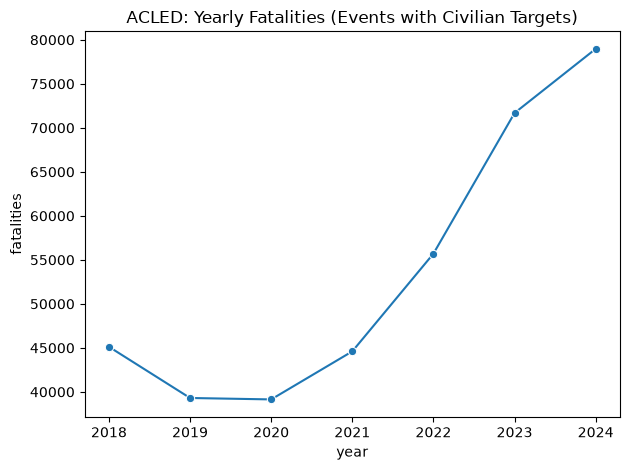

In [6]:
#| label: Q3-response
#| label: Q3-response
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

# Note that here we do *not* need to install and load the httpfs extension.
# That extension was only necessary in Q2 because we were executing queries over
# HTTP (essentially, issuing GET requests to AWS for the S3 bucket contents)
con = duckdb.connect()

# Your code here: You can copy-and-paste your DuckDB query from Q2.2's .py file,
# but make sure you update it to query the Pandas *DataFrame*, civilian_df,
# rather than the remote S3 bucket!
yearly_fatalities_query = """
SELECT
    year,
    SUM(fatalities) AS fatalities
FROM civilian_df
WHERE year BETWEEN 2018 AND 2024
GROUP BY year
ORDER BY year
"""

# If your query is written correctly, the following lines will display the
# resulting data table in the cell's output
result_df = con.execute(yearly_fatalities_query).df()
display(result_df)

# Finally, write code to generate and export the yearly fatalities plot here
sns.lineplot(
    data=result_df,
    x="year",
    y="fatalities",
    marker="o"
)

plt.title("ACLED: Yearly Fatalities (Events with Civilian Targets)")
plt.tight_layout()
plt.savefig("images/yearly_fatalities_civilian.svg")

You made it to the end of HW4! Hopefully this last part "clicked" in your head the beauty of how modular DuckDB queries are: you were able to take the same query and apply it in a completely different context (querying an in-memory Pandas `DataFrame` rather than a remote `.parquet` file) – with an entirely different dataset in fact (though one with the same schema) – to achieve the similar goal of obtaining a plot of yearly fatality counts.

From a pedagogical standpoint, the idea is for you to start seeing the benefits of this **separation of data from computation**: you can think of the **string** containing the DuckDB query as a "piece" of computation, that you were then able to move around and apply to different datasets in different formats, both in-memory and remotely in a file!